<a href="https://colab.research.google.com/github/ismaelpereziimas/Procesamiento-de-Imagenes-Medicas/blob/main/Notebooks/e1_2026_Procesamiento_de_Imagenes_Medicas_MLP_EJERCICIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Procesamiento de imágenes médicas**
----------
# Ejercicio redes neuronales
-------

Por:

Ahora te toca a ti, trabajaremos ahora con el dataset Breast Cancer Wisconsin. Esta base de datos contiene 30 características numéricas (radio, textura, perímetro, área, suavidad, etc.) calculadas a partir de imágenes digitalizadas de aspiraciones con aguja fina de masas mamarias. El objetivo es clasificar si el tumor es maligno o benigno.

La podrás encontrar en kaggle: https://www.kaggle.com/code/nadaemad2002/breast-cancer-wisconsin/input?select=data.csv


Los datos que usaremos se encuentran en: https://drive.google.com/file/d/1HGlz0r3Ry6GMA13oWkeiOBK1NOPAoHNw/view?usp=sharing








# Importación de las librerías y el dataset

En este paso importaremos las librerías necesarias para la graficación, trabajo con DataFrames, carga del dataset, métricas, generaci+on de redes neuronales, etc.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Tensorflow nos ayudará con la contruccion de la red neuronal.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#Sklearn nos ayudará para importar el dataset, y utilizar herramientas como
#datasets, métricas, estandarización, división del dataset, etc.
from sklearn import datasets
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical


from google.colab import drive
drive.mount('/content/drive')




Mounted at /content/drive


In [2]:
cancer_df=pd.read_csv('/content/drive/MyDrive/2026_PROCESAMIENTO DE IMAGENES/Breast Cancer Wisconsin/data.csv')

# Análisis exploratorio de los datos
En esta etapa se visualizan los datos de diferentes formas para ver las relaciones que tienen entre sí, así como diferentes métricas.

En esta ocasión, solo se mostrará la tabla con los valores obtenidos y posteriormente se graficará la distribución de los por característica y clase. También se graficará la clasificación por cada par de características.

In [3]:
cancer_df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
cancer_df.drop(['id'], axis=1,inplace=True)

In [5]:
cancer_df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
cancer_df.dropna(axis=1, how='all', inplace=True)

In [8]:
cancer_df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
columnas_grafica=['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean']
cancer_cinco_df=cancer_df[columnas_grafica]
cancer_cinco_df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980


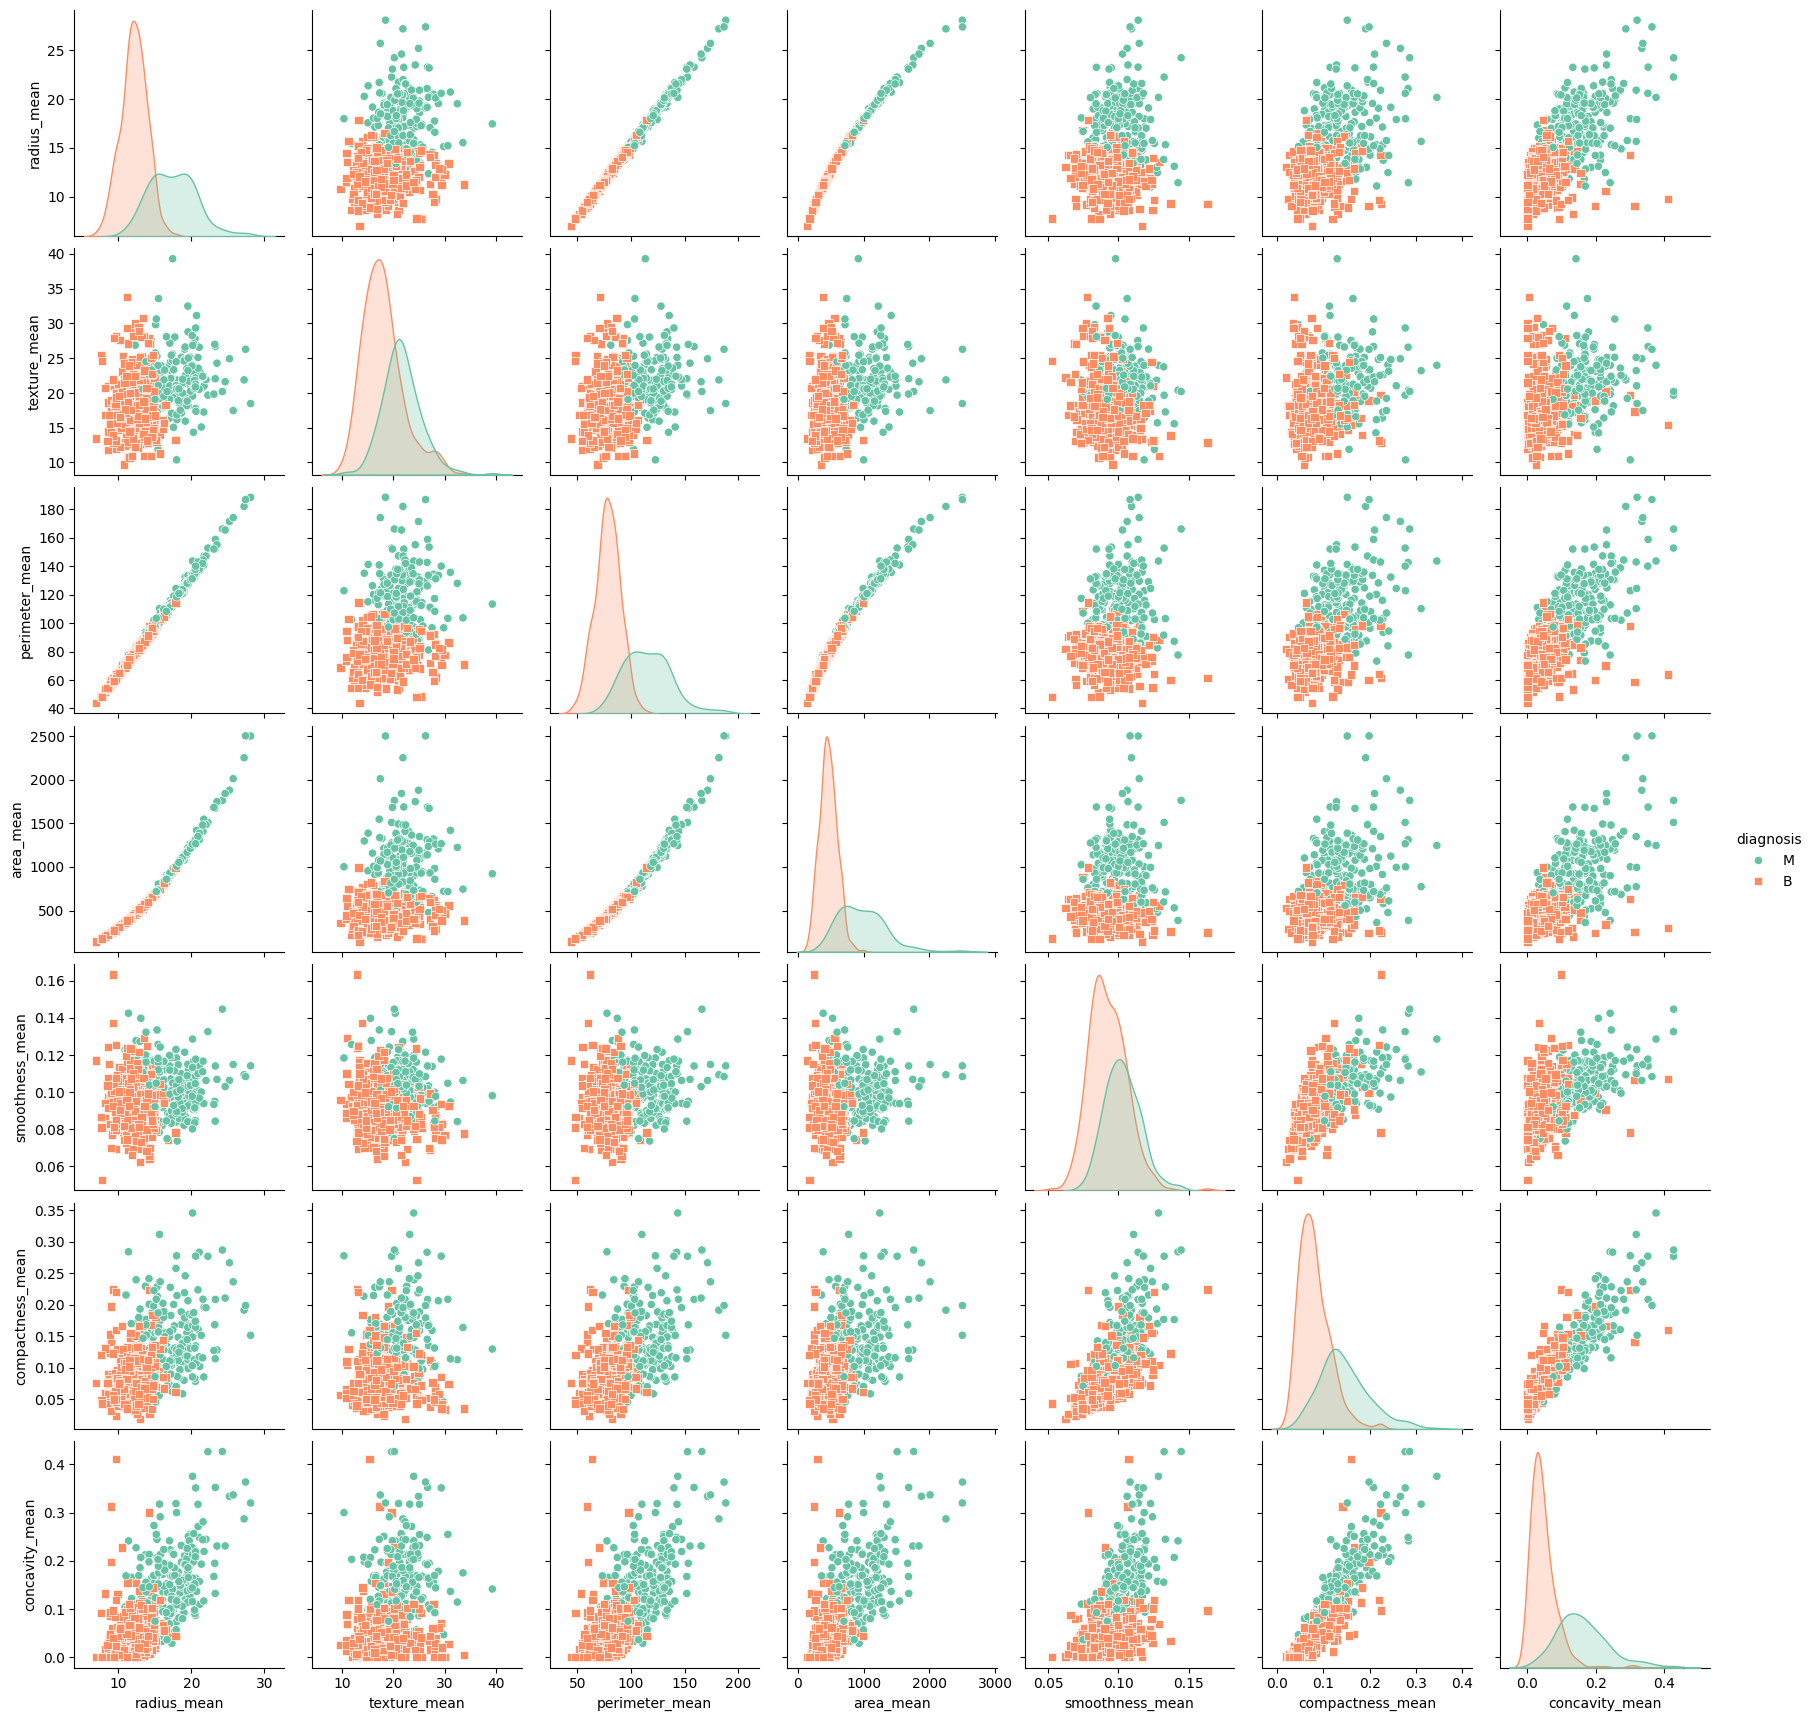

In [14]:
sns.pairplot(cancer_cinco_df, hue='diagnosis', markers=['o', 's'], palette='Set2')